In [14]:
# Colab cell (code)
# 1) Install packages (run once)
# !pip install -q transformers==4.40.0 gradio torch torchvision tqdm

# 2) Show GPU info
import torch, sys, os
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.12
Torch: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


In [15]:
!pip install -q "transformers>=4.41.0,<5" sentence-transformers gradio tqdm

In [2]:
# Run this cell and use the file browser (left sidebar) -> Upload
from google.colab import files
uploaded = files.upload()  # select archive.zip from your local machine


Saving archive.zip to archive.zip


In [3]:
# Colab cell (code)
import os, zipfile, glob

# If you used files.upload() the filename is in uploaded.keys(), otherwise set zip_path manually
try:
    zip_path = list(uploaded.keys())[0]
except:
    # replace with your drive path if using Drive
    zip_path = "/content/archive.zip"  # change if needed

extract_path = "/content/brain_tumor_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

# show top-level
print("Top-level folders:", os.listdir(extract_path))
print("\nExample structure (only first few):")
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("  subdirs:", dirs[:10])
    print("  example files:", files[:5])
    break


Top-level folders: ['Testing', 'Training']

Example structure (only first few):
/content/brain_tumor_data
  subdirs: ['Testing', 'Training']
  example files: []


Train counts: {'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}
Test counts:  {'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}


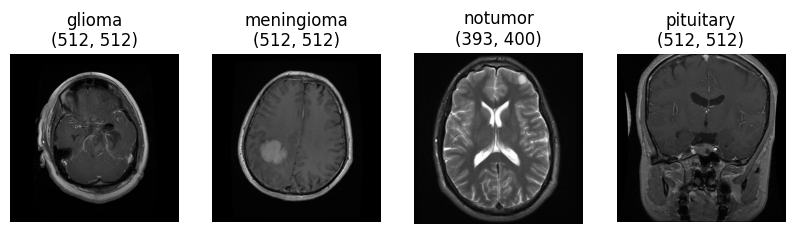

In [4]:
# Colab cell (code)
from PIL import Image
import matplotlib.pyplot as plt
import os, random

root = extract_path  # from previous cell
train_dir = os.path.join(root, "Training")
test_dir = os.path.join(root, "Testing")

def class_counts(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path) if not f.startswith('.')])
    return counts

print("Train counts:", class_counts(train_dir))
print("Test counts: ", class_counts(test_dir))

# Show one sample per class from training
plt.figure(figsize=(10,6))
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir,d))])
for i,cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    files = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    if len(files)==0:
        continue
    img = Image.open(os.path.join(cls_path, files[0])).convert('L')  # grayscale preview
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{cls}\n{img.size}")
    plt.axis('off')
plt.show()


In [5]:
# Colab cell (code)
from torchvision import transforms
import torch

IMAGE_SIZE = 224
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),          # ensures 3 channels (MRI is grayscale)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# quick check on one image
from PIL import Image
example_path = None
for cls in os.listdir(train_dir):
    p = os.path.join(train_dir, cls)
    if os.path.isdir(p):
        files = [f for f in os.listdir(p) if not f.startswith('.')]
        if files:
            example_path = os.path.join(p, files[0])
            break

img = Image.open(example_path)
t = transform(img)
print("Transformed shape:", t.shape, "dtype:", t.dtype)
print("Min, max (tensor):", float(t.min()), float(t.max()))


Transformed shape: torch.Size([3, 224, 224]) dtype: torch.float32
Min, max (tensor): -2.1179039478302 1.960261583328247


🖤 transforms.Grayscale(num_output_channels=3)

MRI images are grayscale — they only have intensity, not color.
Each pixel = 1 number between 0 and 255 (brightness).

But pretrained Vision Transformers (like ViT) expect 3-channel RGB images (R, G, B).
So this step duplicates the single grayscale channel 3 times to make it look like RGB to the model.

👉 Shape changes from (1, H, W) → (3, H, W).

📏 transforms.Resize((224, 224))

Resizes the image to 224×224 pixels.
ViT models (like vit_b_16) expect a fixed input size of 224×224.

👉 Shape after this = (3, 224, 224) (height=224, width=224, 3 color channels).

🔢 transforms.ToTensor()

Converts the PIL image (which stores pixel values as integers in [0, 255]) into a PyTorch tensor (numerical matrix) with:

Values rescaled to [0.0, 1.0]

Shape reordered to (C, H, W) (channels first)

👉 For example: a pixel with intensity 128 becomes 128 / 255 = 0.5019

transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

This adjusts the pixel values so they’re standardized to match what the pretrained ViT expects (it was trained on ImageNet with these stats).

Each channel (R, G, B) is normalized as:

new_value=(old_value-mean)/std
So:

A pixel value around the mean becomes ~0.0

Brighter pixels become positive

Darker pixels become negative

This is why your output tensor shows min ≈ -2.1 and max ≈ +1.96
These values reflect standardized pixel intensity — now roughly centered around 0.

A tensor is the fundamental data structure in PyTorch — you can think of it as a multi-dimensional array (like a NumPy array) that lives on the CPU or GPU.

Tensor Type	Example	Description
0D	torch.tensor(5)	Scalar (single number)
1D	[1, 2, 3]	Vector
2D	[[1,2,3],[4,5,6]]	Matrix
3D	image tensor (C, H, W)	3D array of numbers for an image
4D	(batch, C, H, W)	Batch of images

So your image tensor of shape (3, 224, 224) means:

3 → channels (Red, Green, Blue)

224 → height

224 → width

Each value inside that tensor is a float32 number representing the normalized brightness of a pixel.

The ViT model processes these tensors — not images — because it works numerically on arrays.

In [6]:
# Colab cell (code)
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

CLASS_MAP = {name: idx for idx, name in enumerate(sorted(os.listdir(train_dir)))}
print("Class map (auto):", CLASS_MAP)

class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, split='Training', transform=None, class_map=CLASS_MAP):
        self.transform = transform
        self.samples = []
        self.labels = []
        base = os.path.join(root_dir, split)
        for cls_name, cls_idx in class_map.items():
            cls_folder = os.path.join(base, cls_name)
            if not os.path.isdir(cls_folder):
                continue
            for fname in os.listdir(cls_folder):
                if fname.startswith('.'):
                    continue
                self.samples.append(os.path.join(cls_folder, fname))
                self.labels.append(cls_idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p = self.samples[idx]
        lab = self.labels[idx]
        img = Image.open(p)
        # ensure consistent mode — handle grayscale or RGB
        img = img.convert('L')  # keep as single-channel, then Grayscale transform makes 3 channels
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(lab, dtype=torch.long)

# instantiate and test
dataset = BrainTumorDataset(extract_path, split='Training', transform=transform)
print("Total training samples:", len(dataset))
x,y = dataset[0]
print("Sample shapes:", x.shape, y, type(y))


Class map (auto): {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Total training samples: 5712
Sample shapes: torch.Size([3, 224, 224]) tensor(0) <class 'torch.Tensor'>


This cell builds a memory-efficient, standardized PyTorch dataset that loads and preprocesses images on demand, producing tensors ready for training with CrossEntropyLoss.

Earlier, you were loading all the images into memory at once, converting every MRI image into a tensor immediately, and storing them inside two Python lists — one for images and one for labels. This meant your computer had to hold thousands of large tensors in RAM even before training began. It worked for small datasets but could easily slow down or crash the system if the dataset grew larger.
Now, in this step, you’re doing it in a smarter and more efficient way. Instead of loading everything at once, you’re only storing the file paths of the images and loading them on demand — one batch at a time while training. Whenever the model needs data, your custom BrainTumorDataset class opens those specific image files, applies the transformations (resize, grayscale, normalize), converts them into tensors, and then feeds them to the model. This approach saves memory, speeds up data handling, and integrates perfectly with PyTorch’s DataLoader, which takes care of batching and shuffling automatically.

In [15]:
# Colab cell (code)
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# create indices and stratified split
indices = list(range(len(dataset)))
labels = [dataset.labels[i] for i in range(len(dataset))]
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42)

train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))
# peek a batch
xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)

Train batches: 143 Val batches: 36
Batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [8]:
# Colab cell (code)
import random, numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [12]:
import torch
import torch.nn as nn
from torchvision import models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ViT (torchvision). If torchvision warns about deprecation, it's okay.
model = models.vit_b_16(pretrained=True)   # simple API; change if your torchvision version differs
# Replace head to match 4 classes
in_features = model.heads.head.in_features if hasattr(model, 'heads') else model.head.in_features
model.heads.head = nn.Linear(in_features, 4)

# Move to device
model = model.to(device)

# Loss and optimizer (Adam with L2 = weight_decay)
criterion = nn.CrossEntropyLoss()  # expects integer labels (long) with shape (B,)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Optional: a small printout
print("Model loaded and head replaced. Parameters to train:", sum(p.numel() for p in model.parameters()))
print("Example device check - first param device:", next(model.parameters()).device)

# The torchsummary part has been removed as it was causing issues.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded and head replaced. Parameters to train: 85801732
Example device check - first param device: cuda:0


In [19]:
# -------------------------
# Colab cell: Training + Validation loop
# -------------------------
import time
from tqdm.auto import tqdm
import torch

# Hyperparameters (tweak as needed)
NUM_EPOCHS = 8
BEST_MODEL_PATH = "best_finetuned_vit.pth"
LOG_INTERVAL = 20  # print batch-level update every N batches
USE_AMP = torch.cuda.is_available()  # use mixed precision on GPU

# Scheduler: simple step LR (you can swap for CosineAnnealingLR etc.)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    # ----- Training -----
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Train")
    for step, (images, labels) in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)  # shape: (B,), long

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)                # logits (B,4)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # stats
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += images.size(0)

        if (step + 1) % LOG_INTERVAL == 0 or (step + 1) == len(train_loader):
            pbar.set_postfix({
                "loss_batch": f"{loss.item():.4f}",
                "acc_batch": f"{(preds==labels).float().mean().item():.4f}"
            })

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        pbar_val = tqdm(enumerate(val_loader), total=len(val_loader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Val")
        for step, (images, labels) in pbar_val:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Scheduler step
    scheduler.step()

    # Save history
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": best_val_acc,
            "history": history
        }, BEST_MODEL_PATH)

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train loss: {epoch_train_loss:.4f}, Train acc: {epoch_train_acc:.4f} | "
          f"Val loss: {epoch_val_loss:.4f}, Val acc: {epoch_val_acc:.4f} | "
          f"Time: {epoch_time:.1f}s | Best val acc: {best_val_acc:.4f}")

print("Training complete. Best val acc:", best_val_acc)
print("Best model saved to:", BEST_MODEL_PATH)


/tmp/ipython-input-1144910212.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Epoch 1/8 - Train:   0%|          | 0/143 [00:00<?, ?it/s]

/tmp/ipython-input-1144910212.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 1/8 - Val:   0%|          | 0/36 [00:00<?, ?it/s]

/tmp/ipython-input-1144910212.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01/8 | Train loss: 0.0004, Train acc: 1.0000 | Val loss: 0.0954, Val acc: 0.9790 | Time: 92.4s | Best val acc: 0.9790


Epoch 2/8 - Train:   0%|          | 0/143 [00:00<?, ?it/s]

/tmp/ipython-input-1144910212.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


KeyboardInterrupt: 

Test Accuracy: 0.9863
Weighted Precision: 0.9863, Recall: 0.9863, F1: 0.9863

Per-class report:
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       300
  meningioma       0.97      0.97      0.97       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.98      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



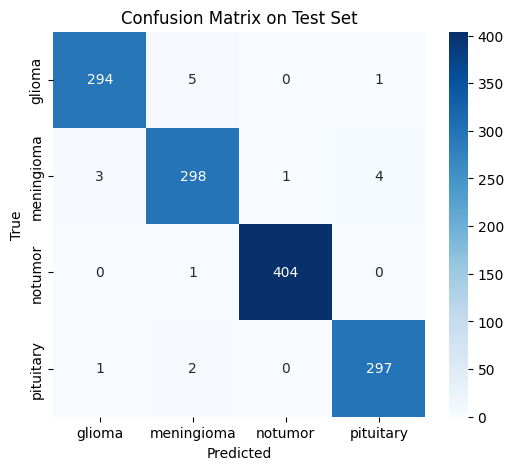

In [17]:
# Colab cell: Evaluate on held-out test set
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Paths & hyperparams
BEST_MODEL_PATH = "best_finetuned_vit.pth"
TEST_ROOT = "/content/brain_tumor_data"   # adjust if different
TEST_SPLIT = "Testing"
BATCH = 64

# Build test dataset (reuse BrainTumorDataset and transform from earlier)
test_dataset = BrainTumorDataset(TEST_ROOT, split=TEST_SPLIT, transform=transform, class_map=CLASS_MAP)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Load best model checkpoint
ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
# If you saved dict with model_state_dict
if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)
model.to(device)
model.eval()

# Inference
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        labs = labs.to(device, non_blocking=True)
        outputs = model(imgs)              # logits
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
print(f"Test Accuracy: {acc:.4f}")
print(f"Weighted Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}\n")
print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=[k for k,_ in sorted(CLASS_MAP.items(), key=lambda x:x[1])]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[k for k,_ in sorted(CLASS_MAP.items(), key=lambda x:x[1])],
            yticklabels=[k for k,_ in sorted(CLASS_MAP.items(), key=lambda x:x[1])], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()


In [20]:
# ✅ Updated Gradio deployment cell (works with latest gradio)
import gradio as gr
import torch.nn.functional as F
from PIL import Image
import numpy as np

# Reverse class map for display
idx2class = {v: k for k, v in CLASS_MAP.items()}

def predict_image(pil_img):
    # Ensure grayscale compatibility
    img = pil_img.convert("L")
    img = transform(img).unsqueeze(0).to(device)  # (1,3,224,224)
    model.eval()
    with torch.no_grad():
        logits = model(img)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_label = idx2class[pred_idx]
        confidence = float(probs[pred_idx])

    # Return both label and confidence values for display
    return {idx2class[i]: float(probs[i]) for i in range(len(probs))}, f"{pred_label} ({confidence:.3f})"

# Gradio interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=[
        gr.Label(num_top_classes=3, label="Top Predictions"),
        gr.Textbox(label="Predicted (Top-1) with Confidence")
    ],
    title="🧠 Brain Tumor Classifier (Vision Transformer)",
    description="Upload an MRI scan (PNG/JPG). Model predicts among 4 classes: Glioma, Meningioma, No Tumor, Pituitary.",
    examples=None,
)

# Launch app (Colab will give a public link)
iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://00f83b9efd102becf3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
